In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read in permutation outputs
obs = pd.read_csv("protein_network_observed_graph_stats.csv")
nulls = pd.read_csv("protein_network_null_graph_stats.csv")
summary = pd.read_csv("protein_network_null_comparison_summary.csv")
composite = pd.read_csv("protein_network_composite_scores.csv")

In [3]:
# Look at comparison p vals
pivot_p = summary.pivot(index="metric", columns="null_type", values="empirical_p_high")
pivot_p.round(4)

null_type,A_global_pathway_permute,B_degree_preserving_rewire,C_within_protein_score_shuffle
metric,,,
lcc_frac,1.000,1.000,1.0000
modularity,1.000,1.000,0.0040
weighted_clustering,0.004,0.004,0.1036
weighted_degree_cv,0.004,0.004,0.3147
weighted_degree_gini,0.004,0.004,0.0040


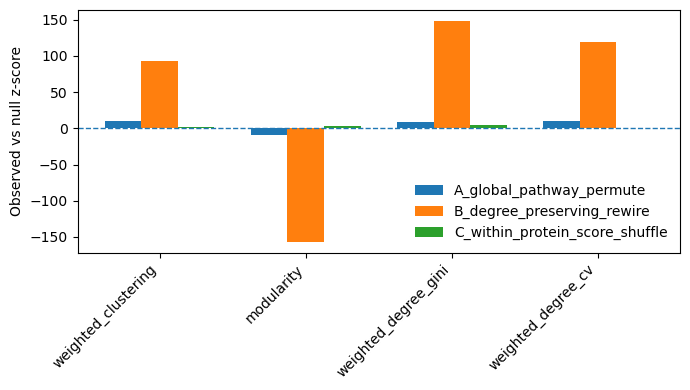

In [4]:
# Plot z score differences
plot_df = summary.copy()

# Remove lcc frac since it is not informative
plot_df = plot_df[plot_df['metric']!='lcc_frac']

# Set orders
metric_order = [
    "weighted_clustering",
    "modularity",
    "weighted_degree_gini",
    "weighted_degree_cv"
]

null_order = [
    "A_global_pathway_permute",
    "B_degree_preserving_rewire",
    "C_within_protein_score_shuffle"
]

# Copy columns
plot_df["metric"] = pd.Categorical(plot_df["metric"], categories=metric_order, ordered=True)
plot_df["null_type"] = pd.Categorical(plot_df["null_type"], categories=null_order, ordered=True)
plot_df = plot_df.sort_values(["metric", "null_type"])

# Set up plot
plt.figure(figsize=(7,4))

x = np.arange(len(metric_order))
width = 0.25

# Format
for i, null_type in enumerate(null_order):
    sub = plot_df[plot_df["null_type"] == null_type]
    plt.bar(x + (i-1)*width, sub["z_score"], width=width, label=null_type)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, metric_order, rotation=45, ha="right")
plt.ylabel("Observed vs null z-score")
plt.legend(frameon=False)

# Show plot
plt.tight_layout()
plt.show()